# Clustering jerárquico (HC) sobre los embeddings del EDA

Se aplica **clustering jerárquico aglomerativo (Ward)** a cada una de las tres técnicas de
embedding del EDA (`eda.ipynb`) y se evalúa con **métricas de aprendizaje no supervisado**:

| Técnica | Representación usada para HC |
|---|---|
| TF-IDF | TruncatedSVD a 50 componentes (LSA) sobre la matriz sparse |
| MiniLM multilingüe | vectores densos de 384 dims |
| BGE-M3 (vLLM) | vectores densos de 1024 dims |

Todos los vectores se **L2-normalizan** antes del linkage, de modo que la distancia
euclídea de Ward sea equivalente (monótona) a la distancia coseno — la métrica natural
para embeddings de texto.

Métricas calculadas para k = 2…15:
- **Silhouette** (↑ mejor, rango [-1, 1]) — cohesión vs. separación por punto.
- **Calinski-Harabasz** (↑ mejor) — razón de dispersión entre/intra clúster.
- **Davies-Bouldin** (↓ mejor) — similitud media entre cada clúster y su más parecido.
- **Correlación cofenética** (↑ mejor) — fidelidad del dendrograma a las distancias originales.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.

In [2]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF (que el EDA no
cachea por ser sparse) se recalcula con los mismos hiperparámetros y se reduce con
`TruncatedSVD` a 50 componentes, la misma reducción previa que el EDA usa para t-SNE.

In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")

# L2-normalización: euclídea sobre vectores unitarios ~ distancia coseno
embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)


## Linkage jerárquico (Ward) y dendrogramas

Se construye la jerarquía completa con `scipy.cluster.hierarchy.linkage(method="ward")`
y se reporta la **correlación cofenética** de cada árbol. Los dendrogramas se truncan a
los últimos 30 merges para legibilidad.

In [4]:
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

linkages, cofeneticas = {}, {}
for nombre, emb in embeddings.items():
    dist = pdist(emb)
    Z = linkage(emb, method="ward")
    linkages[nombre] = Z
    cofeneticas[nombre], _ = cophenet(Z, dist)
    print(f"{nombre}: correlación cofenética = {cofeneticas[nombre]:.3f}")


TF-IDF (SVD-50): correlación cofenética = 0.438


MiniLM multilingüe: correlación cofenética = 0.275


BGE-M3: correlación cofenética = 0.279


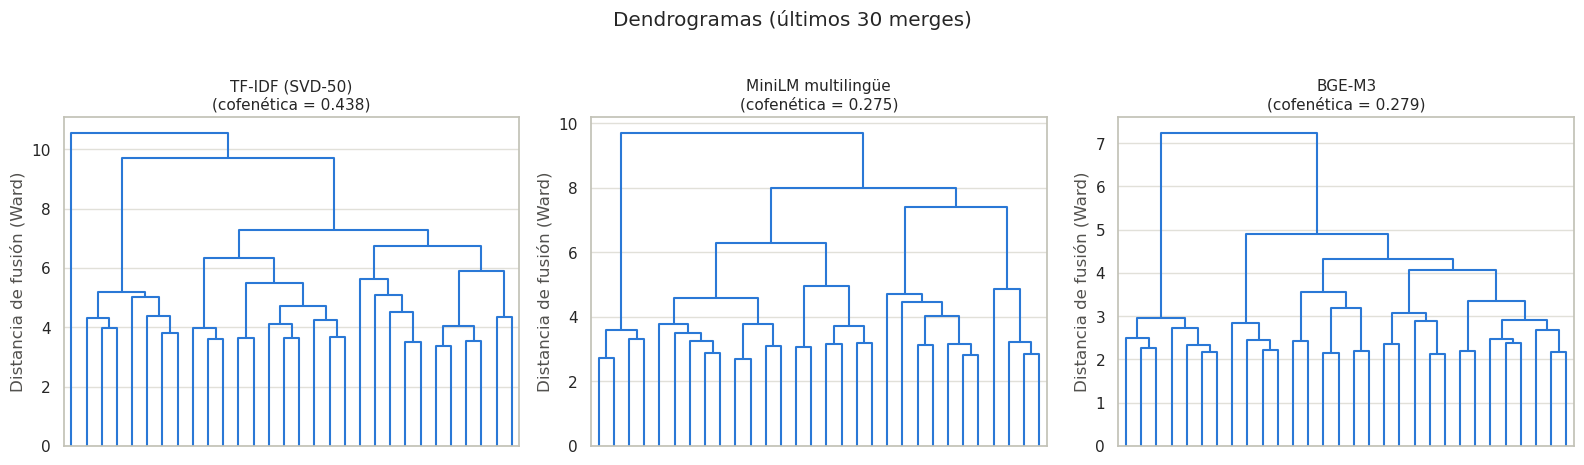

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, no_labels=True,
               color_threshold=0, above_threshold_color="#2a78d6")
    ax.set_title(f"{nombre}\n(cofenética = {cofeneticas[nombre]:.3f})", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas (últimos 30 merges)", y=1.03)
plt.tight_layout()
plt.show()


## Métricas no supervisadas por número de clústeres

Para cada técnica se corta el dendrograma en k = 2…15 y se calculan silhouette
(con distancia coseno), Calinski-Harabasz y Davies-Bouldin.

In [6]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

RANGO_K = range(2, 16)
filas = []
etiquetas_por_k = {}
for nombre, emb in embeddings.items():
    Z = linkages[nombre]
    for k in RANGO_K:
        etiquetas = fcluster(Z, t=k, criterion="maxclust")
        etiquetas_por_k[(nombre, k)] = etiquetas
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.166708,73.053467,1.505325
1,TF-IDF (SVD-50),3,0.126956,70.336307,2.976634
2,TF-IDF (SVD-50),4,0.098279,60.384104,4.098509
3,TF-IDF (SVD-50),5,0.104292,54.393897,3.854032
4,TF-IDF (SVD-50),6,0.086055,50.215205,3.786576


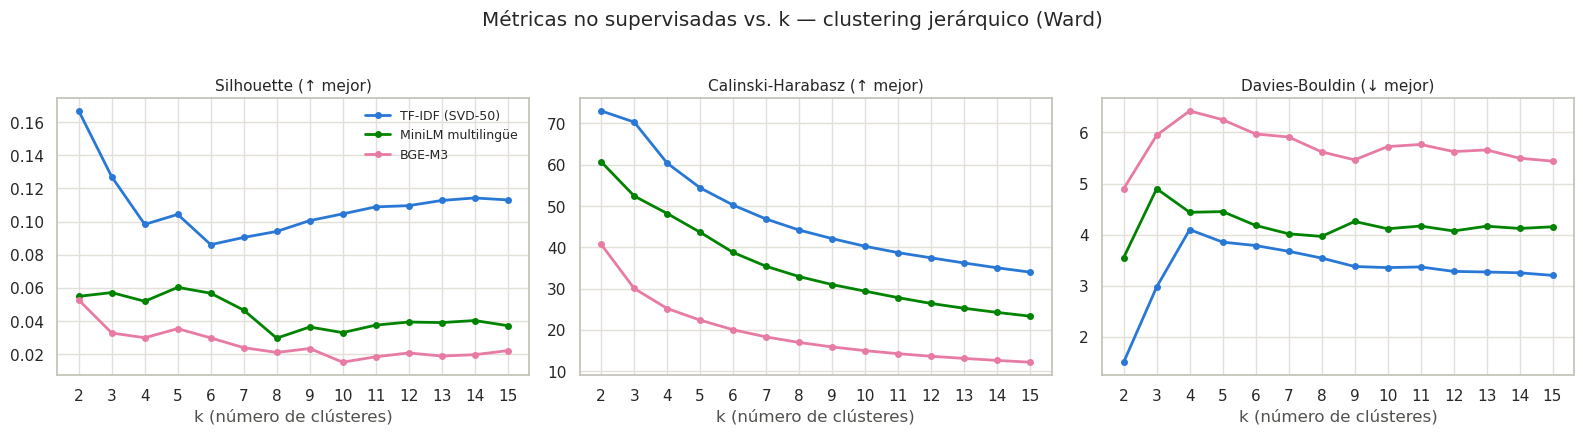

In [7]:
COLORES_TEC = dict(zip(embeddings, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in embeddings:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — clustering jerárquico (Ward)", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette y se reportan las tres métricas en ese corte,
junto con el tamaño de los clústeres resultantes.

In [8]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["cofenetica"] = pd.Series(cofeneticas).round(3)
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,cofenetica
tecnica,,,,,
BGE-M3,2,0.053,40.696,4.898,0.279
MiniLM multilingüe,5,0.060,43.629,4.451,0.275
TF-IDF (SVD-50),2,0.167,73.053,1.505,0.438


In [9]:
for nombre in embeddings:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=2): tamaños de clúster = [1439, 73]
MiniLM multilingüe (k=5): tamaños de clúster = [381, 374, 273, 255, 229]
BGE-M3 (k=2): tamaños de clúster = [1194, 318]


## Árboles completos coloreados por el corte óptimo

Dendrograma **completo** (las 1,512 hojas) de cada técnica. La línea punteada marca la
altura de corte que produce el mejor k según silhouette; las ramas por debajo de esa
altura se colorean por clúster resultante.

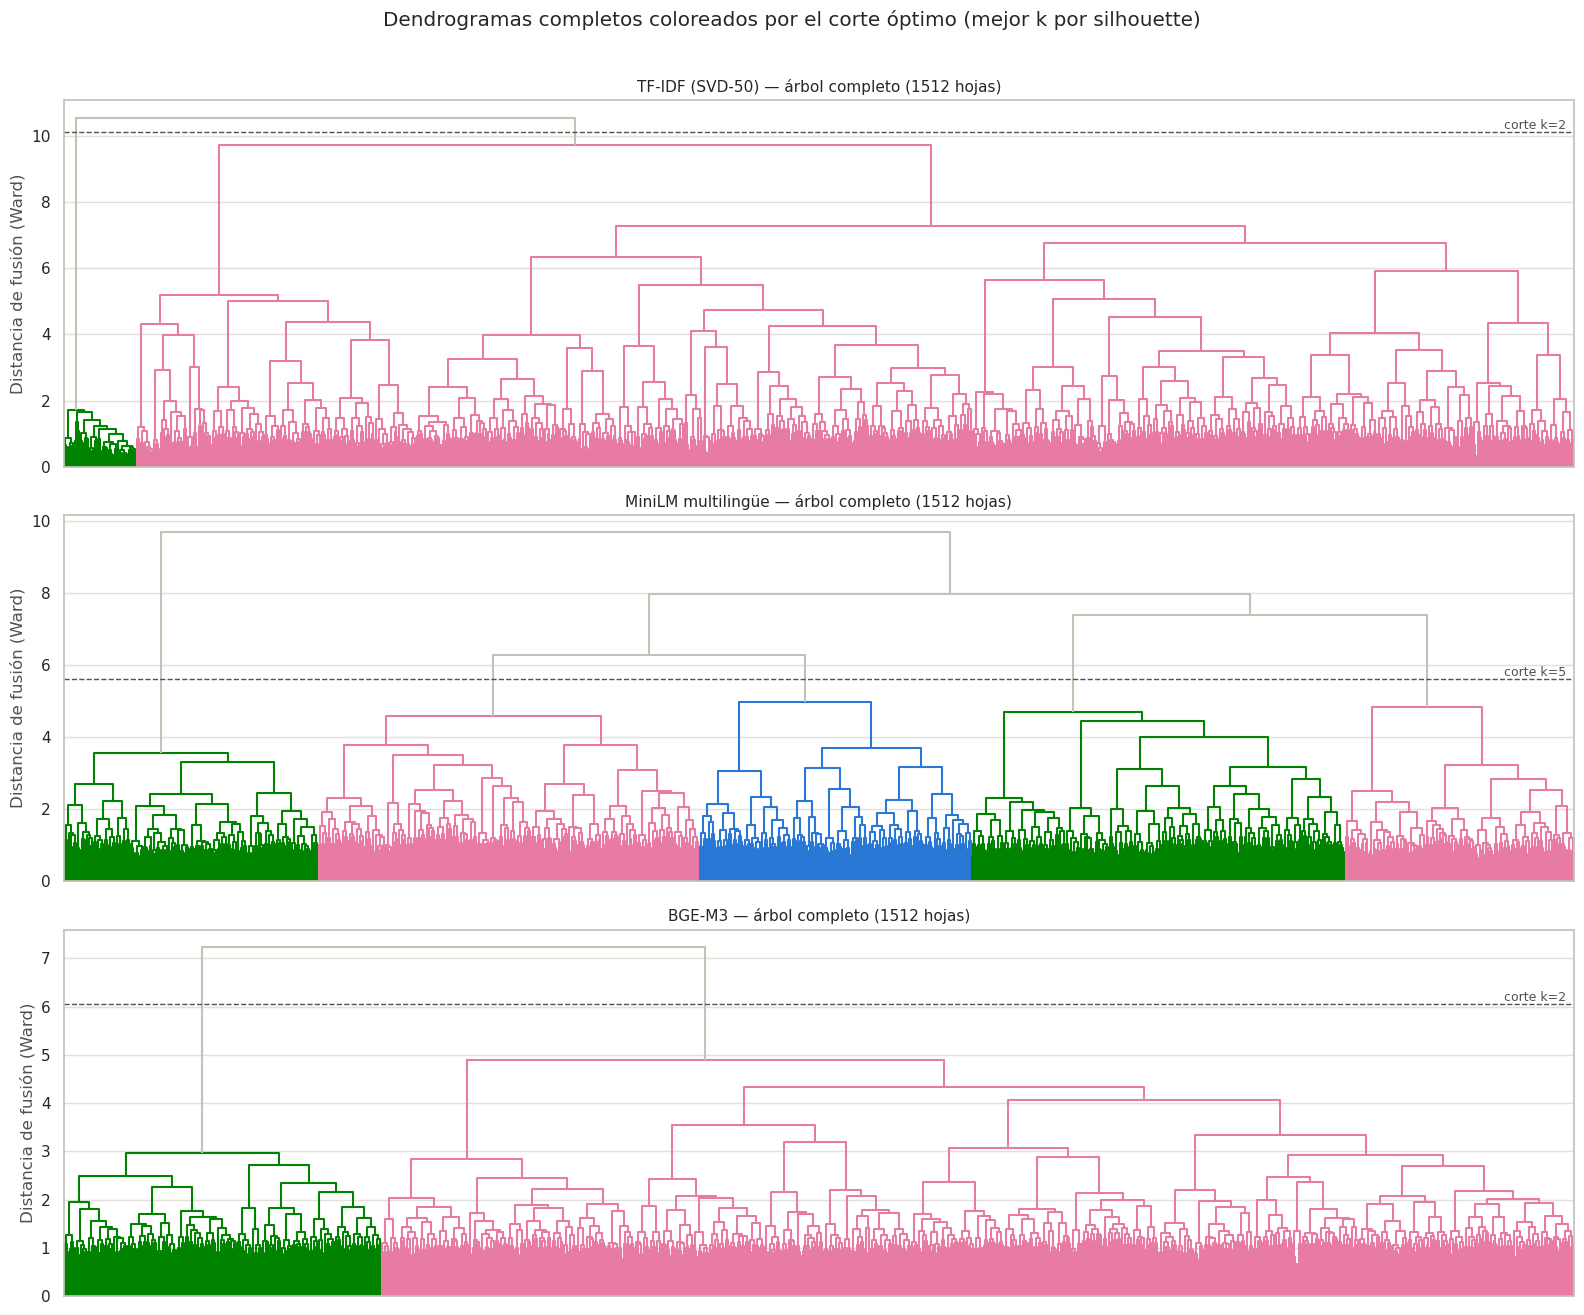

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    k = int(mejores.loc[nombre, "k"])
    # Altura de corte: punto medio entre los merges que dejan k y k-1 clústeres
    umbral = (Z[-k, 2] + Z[-(k - 1), 2]) / 2 if k > 1 else Z[-1, 2] * 1.05
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=umbral,
               above_threshold_color="#c3c2b7")
    ax.axhline(umbral, color="#52514e", linestyle="--", linewidth=1)
    ax.text(0.995, umbral, f" corte k={k}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=9, color="#52514e")
    ax.set_title(f"{nombre} — árbol completo ({Z.shape[0] + 1} hojas)", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas completos coloreados por el corte óptimo (mejor k por silhouette)", y=1.01)
plt.tight_layout()
plt.show()


## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D (misma receta del EDA: reducción previa a 50 dims) coloreada por el
clúster jerárquico en el mejor k de cada técnica.

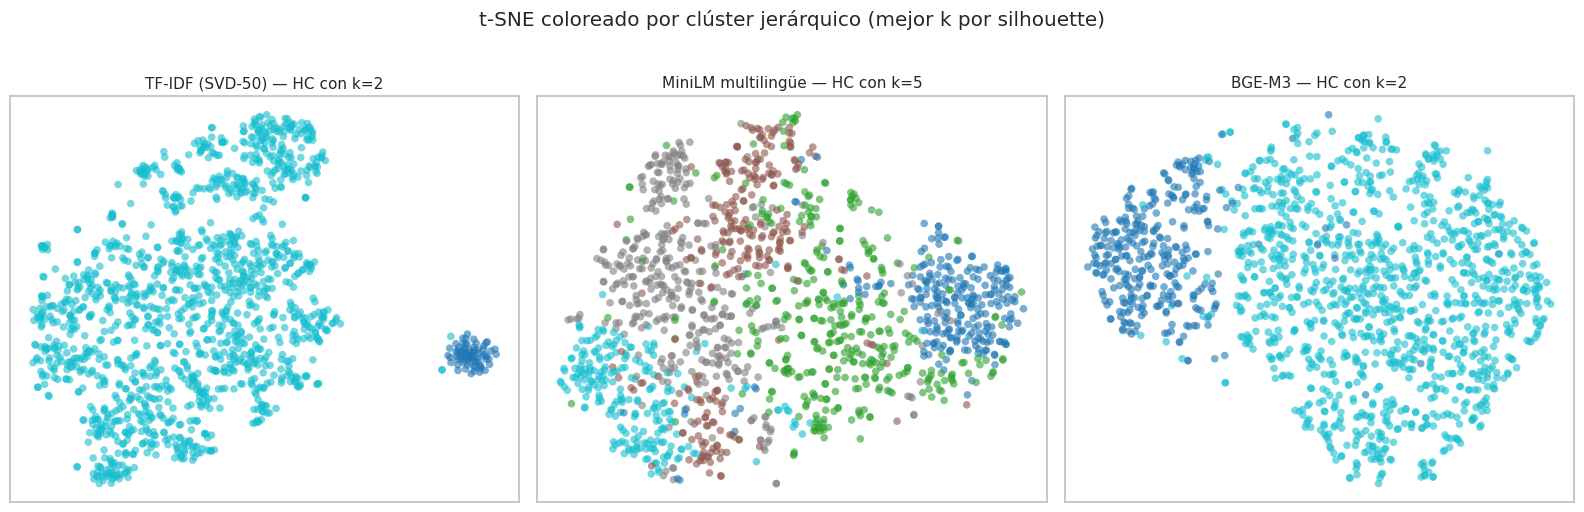

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nombre, emb) in zip(axes, embeddings.items()):
    x50 = emb if emb.shape[1] <= 50 else PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(emb)
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(x50)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ax.set_title(f"{nombre} — HC con k={k}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE coloreado por clúster jerárquico (mejor k por silhouette)", y=1.02)
plt.tight_layout()
plt.show()


## Lectura de resultados

- La **correlación cofenética** indica qué tan fielmente el árbol de Ward representa las
  distancias originales de cada espacio de embeddings.
- Los valores absolutos de silhouette suelen ser bajos en corpus de prensa (los temas se
  solapan); lo relevante es la **comparación relativa entre técnicas** y la forma de las
  curvas (codos o mesetas sugieren un rango razonable de k).
- Calinski-Harabasz no es directamente comparable **entre** técnicas (depende de la escala
  del espacio); úsese solo para comparar valores de k dentro de una misma técnica.
- Este resultado alimenta la decisión del método de embedding definitivo para el pipeline
  de clustering + RAG con Milvus (ver conclusiones del EDA).